# Optimization on Matrix Manifolds
## From Constrained Problems to Unconstrained Geometry

This notebook provides a self-contained introduction to **optimization on matrix manifolds** -- the elegant framework that transforms constrained optimization problems (like finding orthogonal matrices) into unconstrained problems on curved spaces.

**What you'll learn:**
1. Why constrained optimization is better handled as unconstrained on manifolds
2. The geometry of the Stiefel and Grassmann manifolds
3. Riemannian gradients and retraction maps
4. Riemannian gradient descent from scratch
5. Application: Rotation averaging on SO(3)

**The key insight:** Instead of optimizing $f(X)$ subject to $X^T X = I$ using Lagrange multipliers or penalty methods, we treat the constraint set $\{X : X^T X = I\}$ as a **smooth manifold** and do unconstrained optimization on it. The constraint is never violated -- every iterate lives on the manifold by construction.

**Prerequisites:** Linear algebra (SVD, eigendecomposition), multivariable calculus (gradients, chain rule), basic familiarity with optimization.

**References:**
- Absil, Mahony & Sepulchre, *Optimization Algorithms on Matrix Manifolds*, Princeton University Press, 2008.
- Edelman, Arias & Smith, *The Geometry of Algorithms with Orthogonality Constraints*, SIAM J. Matrix Anal. Appl., 1998.
- Boumal, *An Introduction to Optimization on Smooth Manifolds*, Cambridge University Press, 2023.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, logm, polar, sqrtm
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Manifold dimensions
N_DIM = 5                    # Ambient dimension n
P_DIM = 3                    # Subspace dimension p (for Stiefel/Grassmann)

# Optimization parameters
STEP_SIZE = 0.05             # Default step size for gradient descent
MAX_ITER = 500               # Maximum iterations
GRAD_TOL = 1e-8              # Gradient norm tolerance
FD_EPSILON = 1e-7            # Finite difference step

# Rotation averaging
N_ROTATIONS = 20             # Number of noisy rotation measurements
NOISE_LEVEL = 0.1            # Noise magnitude for rotation perturbation

# Visualization
N_SPHERE_POINTS = 50         # Resolution for sphere wireframe
COLOR_PRIMARY = 'steelblue'
COLOR_SECONDARY = 'coral'
COLOR_TERTIARY = 'seagreen'
COLOR_ACCENT = 'goldenrod'

---
## 1. Introduction: Why Manifolds?

Many problems in science and engineering involve **matrix constraints**:

| Problem | Constraint | Manifold |
|---------|-----------|----------|
| PCA / Dimensionality reduction | $X^T X = I_p$ | Stiefel manifold $\text{St}(n, p)$ |
| Subspace tracking | Column space of $X$ | Grassmann manifold $\text{Gr}(n, p)$ |
| Rotation estimation | $R \in SO(3)$ | Special orthogonal group |
| Low-rank approximation | $\text{rank}(X) = r$ | Fixed-rank manifold |

**The traditional approach** is to treat these as constrained optimization problems and use Lagrange multipliers, penalty methods, or projection after each step. This has several drawbacks:

1. **Lagrange multipliers** introduce auxiliary variables and require solving KKT systems
2. **Penalty methods** only approximately satisfy constraints and require tuning penalty weights
3. **Projection** can be expensive and may not preserve descent directions

**The manifold approach** recognizes that the constraint set is itself a smooth surface (a manifold) and performs optimization directly on it. The constraint is satisfied **exactly** at every iterate, and we only need to compute:

1. The **Riemannian gradient** (project the Euclidean gradient onto the tangent space)
2. A **retraction** (move along the tangent direction and map back to the manifold)

$$\boxed{X_{k+1} = \text{Retract}_{X_k}\!\left(-\alpha_k \, \text{grad} f(X_k)\right)}$$

---
## 2. Smooth Manifolds Crash Course

### Definition

A **smooth manifold** $\mathcal{M}$ of dimension $d$ is a set that locally looks like $\mathbb{R}^d$. More precisely, every point $x \in \mathcal{M}$ has a neighborhood that can be mapped bijectively (via a **chart**) to an open subset of $\mathbb{R}^d$, and these charts are smoothly compatible.

### Tangent Space

At each point $x \in \mathcal{M}$, the **tangent space** $T_x \mathcal{M}$ is the vector space of all directions in which one can move while staying (infinitesimally) on the manifold. It is a $d$-dimensional subspace of the ambient space.

### Key Examples

**Example 1: The unit sphere** $S^{n-1} = \{x \in \mathbb{R}^n : \|x\| = 1\}$

- Dimension: $n-1$
- Tangent space at $x$: $T_x S^{n-1} = \{v \in \mathbb{R}^n : x^T v = 0\}$ (all vectors orthogonal to $x$)
- Projection onto tangent space: $\text{proj}_x(v) = v - (x^T v) x$

**Example 2: The special orthogonal group** $SO(n) = \{R \in \mathbb{R}^{n \times n} : R^T R = I, \det R = 1\}$

- Dimension: $n(n-1)/2$
- Tangent space at $R$: $T_R SO(n) = \{R \Omega : \Omega^T = -\Omega\}$ (right-translated skew-symmetric matrices)
- The tangent vectors are products of $R$ with skew-symmetric matrices $\Omega$

The connection to **Lie groups** is immediate: $SO(n)$ is a Lie group, and its Lie algebra $\mathfrak{so}(n)$ consists of all $n \times n$ skew-symmetric matrices. The tangent space at any $R$ is obtained by left- or right-translating the Lie algebra.

In [3]:
# =============================================================================
# Section 2: Tangent Space Demonstrations
# =============================================================================

def sphere_tangent_project(x, v):
    """Project vector v onto the tangent space of S^{n-1} at x.

    The tangent space at x on the sphere is {v : x^T v = 0}.
    Projection: proj_x(v) = v - (x^T v) x.

    Args:
        x: Point on the unit sphere. Shape: (n,).
        v: Ambient vector to project. Shape: (n,).

    Returns:
        Projected vector in T_x S^{n-1}. Shape: (n,).
    """
    return v - np.dot(x, v) * x


def so3_tangent_check(R, V):
    """Check if V is in the tangent space of SO(3) at R.

    V in T_R SO(3) iff R^T V is skew-symmetric.

    Args:
        R: Rotation matrix. Shape: (3, 3).
        V: Candidate tangent vector. Shape: (3, 3).

    Returns:
        True if V is (approximately) in the tangent space.
    """
    Omega = R.T @ V
    skew_error = np.max(np.abs(Omega + Omega.T))
    return skew_error < 1e-10


# Demonstrate sphere tangent space
x_sphere = np.array([1.0, 0.0, 0.0])
v_ambient = np.array([0.5, 0.3, 0.7])
v_tangent = sphere_tangent_project(x_sphere, v_ambient)

print("=== Sphere S^2 ===")
print(f"Point x = {x_sphere}")
print(f"Ambient vector v = {v_ambient}")
print(f"Projected tangent = {v_tangent}")
print(f"x^T v_tangent = {np.dot(x_sphere, v_tangent):.2e} (should be 0)")

# Demonstrate SO(3) tangent space
theta = 0.3
R_test = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
])
Omega_test = np.array([
    [0, -0.5, 0.3],
    [0.5, 0, -0.2],
    [-0.3, 0.2, 0]
])
V_tangent = R_test @ Omega_test

print("\n=== SO(3) ===")
print(f"R^T R = I check: max error = {np.max(np.abs(R_test.T @ R_test - np.eye(3))):.2e}")
print(f"V = R @ Omega is tangent: {so3_tangent_check(R_test, V_tangent)}")
print(f"Random matrix is tangent: {so3_tangent_check(R_test, np.random.randn(3, 3))}")

=== Sphere S^2 ===
Point x = [1. 0. 0.]
Ambient vector v = [0.5 0.3 0.7]
Projected tangent = [0.  0.3 0.7]
x^T v_tangent = 0.00e+00 (should be 0)

=== SO(3) ===
R^T R = I check: max error = 0.00e+00
V = R @ Omega is tangent: True
Random matrix is tangent: False


---
## 3. The Stiefel Manifold

The **Stiefel manifold** is the set of orthonormal frames:

$$\text{St}(n, p) = \{X \in \mathbb{R}^{n \times p} : X^T X = I_p\}$$

This is the natural home for problems involving orthogonal columns, such as:
- Finding the top $p$ eigenvectors of a symmetric matrix
- Orthogonal Procrustes problems
- Principal Component Analysis

**Special cases:**
- $\text{St}(n, 1) = S^{n-1}$ (the unit sphere)
- $\text{St}(n, n) = O(n)$ (the orthogonal group)

**Dimension:** $\dim \text{St}(n, p) = np - p(p+1)/2$

### Tangent Space

Differentiating the constraint $X^T X = I_p$ along a curve $X(t)$:

$$\dot{X}^T X + X^T \dot{X} = 0$$

So $X^T \dot{X}$ must be **skew-symmetric**. The tangent space at $X$ is:

$$T_X \text{St}(n, p) = \{Z \in \mathbb{R}^{n \times p} : X^T Z + Z^T X = 0\}$$

Equivalently, $X^T Z$ is skew-symmetric.

### Orthogonal Projection onto the Tangent Space

Given an arbitrary matrix $V \in \mathbb{R}^{n \times p}$, its orthogonal projection onto $T_X \text{St}(n, p)$ is:

$$\boxed{\text{proj}_X(V) = V - X \, \text{sym}(X^T V)}$$

where $\text{sym}(A) = \frac{1}{2}(A + A^T)$ denotes the symmetric part.

In [4]:
# =============================================================================
# Section 3: Stiefel Manifold
# =============================================================================

def stiefel_project(X, V):
    """Project matrix V onto the tangent space of St(n,p) at X.

    proj_X(V) = V - X * sym(X^T V), where sym(A) = (A + A^T)/2.

    Args:
        X: Point on the Stiefel manifold. Shape: (n, p).
        V: Ambient matrix to project. Shape: (n, p).

    Returns:
        Projected matrix in T_X St(n,p). Shape: (n, p).
    """
    sym_part = 0.5 * (X.T @ V + V.T @ X)
    return V - X @ sym_part


def random_stiefel(n, p):
    """Generate a random point on St(n, p) via QR decomposition.

    Args:
        n: Ambient dimension. Integer.
        p: Number of columns. Integer (p <= n).

    Returns:
        Random point on St(n, p). Shape: (n, p).
    """
    A = np.random.randn(n, p)
    Q, R = np.linalg.qr(A)
    # Ensure unique QR by making diagonal of R positive
    signs = np.sign(np.diag(R))
    signs[signs == 0] = 1
    return Q * signs


# Verify tangent space projection
X_st = random_stiefel(N_DIM, P_DIM)
V_ambient = np.random.randn(N_DIM, P_DIM)
Z = stiefel_project(X_st, V_ambient)

# Check 1: X^T Z is skew-symmetric
XtZ = X_st.T @ Z
skew_err = np.max(np.abs(XtZ + XtZ.T))
status1 = "PASS" if skew_err < 1e-12 else "FAIL"
print(f"Stiefel tangent projection: X^T Z skew-symmetry error = {skew_err:.2e} [{status1}]")

# Check 2: Projection is idempotent (proj(proj(V)) = proj(V))
Z2 = stiefel_project(X_st, Z)
idemp_err = np.max(np.abs(Z2 - Z))
status2 = "PASS" if idemp_err < 1e-12 else "FAIL"
print(f"Stiefel tangent projection: idempotency error = {idemp_err:.2e} [{status2}]")

# Check 3: X^T X = I_p (X is on the manifold)
orth_err = np.max(np.abs(X_st.T @ X_st - np.eye(P_DIM)))
status3 = "PASS" if orth_err < 1e-12 else "FAIL"
print(f"Stiefel manifold membership: X^T X = I error = {orth_err:.2e} [{status3}]")

Stiefel tangent projection: X^T Z skew-symmetry error = 4.30e-16 [PASS]
Stiefel tangent projection: idempotency error = 2.22e-16 [PASS]
Stiefel manifold membership: X^T X = I error = 6.66e-16 [PASS]


---
## 4. The Grassmann Manifold

The **Grassmann manifold** $\text{Gr}(n, p)$ is the set of all $p$-dimensional subspaces of $\mathbb{R}^n$.

### Quotient Structure

Two matrices $X, Y \in \text{St}(n, p)$ represent the **same** subspace if and only if $Y = X O$ for some $O \in O(p)$. Thus:

$$\text{Gr}(n, p) = \text{St}(n, p) \, / \, O(p)$$

We can represent a point on $\text{Gr}(n, p)$ by any orthonormal basis $X$ of the subspace. The key insight is that $\text{Gr}(n, p)$ inherits its geometry from $\text{St}(n, p)$ through this quotient.

**Dimension:** $\dim \text{Gr}(n, p) = p(n - p)$

### Horizontal Space

The tangent space of $\text{St}(n, p)$ at $X$ splits into:
- **Vertical space** $\mathcal{V}_X = \{X \Omega : \Omega^T = -\Omega\}$ -- directions that change the basis but not the subspace
- **Horizontal space** $\mathcal{H}_X = \{Z \in T_X \text{St} : X^T Z = 0\}$ -- directions that genuinely change the subspace

The tangent space of the Grassmannian is identified with the horizontal space:

$$T_{[X]} \text{Gr}(n, p) \cong \mathcal{H}_X = \{Z \in \mathbb{R}^{n \times p} : X^T Z = 0\}$$

### Projection onto the Horizontal Space

$$\boxed{\text{proj}_X^{\text{Gr}}(V) = (I - X X^T) V}$$

In [5]:
# =============================================================================
# Section 4: Grassmann Manifold
# =============================================================================

def grassmann_project(X, V):
    """Project matrix V onto the horizontal space of Gr(n,p) at X.

    proj_X^Gr(V) = (I - X X^T) V.

    Args:
        X: Orthonormal basis for the subspace. Shape: (n, p).
        V: Ambient matrix to project. Shape: (n, p).

    Returns:
        Projected matrix in the horizontal space. Shape: (n, p).
    """
    return V - X @ (X.T @ V)


# Verify Grassmann projection
X_gr = random_stiefel(N_DIM, P_DIM)
V_gr = np.random.randn(N_DIM, P_DIM)
Z_gr = grassmann_project(X_gr, V_gr)

# Check 1: X^T Z = 0 (horizontal condition)
horiz_err = np.max(np.abs(X_gr.T @ Z_gr))
status_h = "PASS" if horiz_err < 1e-12 else "FAIL"
print(f"Grassmann horizontal projection: X^T Z = 0 error = {horiz_err:.2e} [{status_h}]")

# Check 2: Projection is idempotent
Z_gr2 = grassmann_project(X_gr, Z_gr)
idemp_err_gr = np.max(np.abs(Z_gr2 - Z_gr))
status_gi = "PASS" if idemp_err_gr < 1e-12 else "FAIL"
print(f"Grassmann horizontal projection: idempotency error = {idemp_err_gr:.2e} [{status_gi}]")

# Show dimension counting
dim_stiefel = N_DIM * P_DIM - P_DIM * (P_DIM + 1) // 2
dim_grassmann = P_DIM * (N_DIM - P_DIM)
dim_vertical = P_DIM * (P_DIM - 1) // 2
print(f"\nDimension accounting for St({N_DIM},{P_DIM}) and Gr({N_DIM},{P_DIM}):")
print(f"  dim St({N_DIM},{P_DIM}) = {dim_stiefel}")
print(f"  dim Gr({N_DIM},{P_DIM}) = {dim_grassmann}")
print(f"  dim O({P_DIM})   = {dim_vertical}")
print(f"  Check: {dim_stiefel} = {dim_grassmann} + {dim_vertical} = {dim_grassmann + dim_vertical} "
      f"[{'PASS' if dim_stiefel == dim_grassmann + dim_vertical else 'FAIL'}]")

Grassmann horizontal projection: X^T Z = 0 error = 8.81e-16 [PASS]
Grassmann horizontal projection: idempotency error = 9.16e-16 [PASS]

Dimension accounting for St(5,3) and Gr(5,3):
  dim St(5,3) = 9
  dim Gr(5,3) = 6
  dim O(3)   = 3
  Check: 9 = 6 + 3 = 9 [PASS]


---
## 5. Riemannian Gradient

### From Euclidean to Riemannian

Given a function $f : \mathbb{R}^{n \times p} \to \mathbb{R}$ that we want to minimize on a manifold $\mathcal{M}$, we need to distinguish two gradients:

- **Euclidean gradient** $\nabla f(X) \in \mathbb{R}^{n \times p}$: the ordinary gradient in the ambient space
- **Riemannian gradient** $\text{grad} f(X) \in T_X \mathcal{M}$: the component of $\nabla f$ that lies in the tangent space

The Riemannian gradient is the steepest ascent direction **on the manifold**. It is obtained by orthogonally projecting the Euclidean gradient onto the tangent space:

$$\text{grad} f(X) = \text{proj}_X(\nabla f(X))$$

### Riemannian Gradient on the Stiefel Manifold

For the Stiefel manifold with the canonical metric:

$$\boxed{\text{grad} f(X) = \nabla f(X) - X \, \text{sym}(X^T \nabla f(X))}$$

### Riemannian Gradient on the Grassmann Manifold

$$\boxed{\text{grad} f(X) = (I - X X^T) \nabla f(X)}$$

### Why does this work?

The Riemannian gradient satisfies: for all $Z \in T_X \mathcal{M}$,

$$\langle \text{grad} f(X), Z \rangle = Df(X)[Z]$$

where $Df(X)[Z]$ is the directional derivative. Since $\text{grad} f(X)$ encodes the same directional information as $\nabla f(X)$ for tangent directions, it gives the correct steepest ascent direction on the manifold.

In [6]:
# =============================================================================
# Section 5: Riemannian Gradient
# =============================================================================

def rayleigh_quotient_cost(X, A):
    """Compute the Rayleigh quotient cost: f(X) = -tr(X^T A X).

    Minimizing this on St(n,p) finds the p leading eigenvectors of A.

    Args:
        X: Point on the Stiefel manifold. Shape: (n, p).
        A: Symmetric matrix. Shape: (n, n).

    Returns:
        Cost value. Scalar.
    """
    return -np.trace(X.T @ A @ X)


def rayleigh_quotient_egrad(X, A):
    """Compute the Euclidean gradient of f(X) = -tr(X^T A X).

    nabla f(X) = -2 A X.

    Args:
        X: Point on the Stiefel manifold. Shape: (n, p).
        A: Symmetric matrix. Shape: (n, n).

    Returns:
        Euclidean gradient. Shape: (n, p).
    """
    return -2.0 * A @ X


def rayleigh_quotient_rgrad(X, A):
    """Compute the Riemannian gradient on St(n,p) of f(X) = -tr(X^T A X).

    grad f(X) = proj_X(nabla f(X)) = nabla f - X * sym(X^T nabla f).

    Args:
        X: Point on the Stiefel manifold. Shape: (n, p).
        A: Symmetric matrix. Shape: (n, n).

    Returns:
        Riemannian gradient. Shape: (n, p).
    """
    egrad = rayleigh_quotient_egrad(X, A)
    return stiefel_project(X, egrad)


# Generate a random symmetric positive definite matrix
M_rand = np.random.randn(N_DIM, N_DIM)
A_sym = M_rand @ M_rand.T + 0.1 * np.eye(N_DIM)

X_test = random_stiefel(N_DIM, P_DIM)
egrad = rayleigh_quotient_egrad(X_test, A_sym)
rgrad = rayleigh_quotient_rgrad(X_test, A_sym)

# Verify Riemannian gradient is in the tangent space
XtG = X_test.T @ rgrad
skew_err_grad = np.max(np.abs(XtG + XtG.T))
status_rg = "PASS" if skew_err_grad < 1e-12 else "FAIL"
print(f"Riemannian gradient tangency: X^T grad skew error = {skew_err_grad:.2e} [{status_rg}]")

# Verify via finite differences on the manifold
# For each tangent direction e_ij, compare <grad f, e_ij> with Df(X)[e_ij]
max_fd_err = 0.0
for _ in range(20):
    V_rand = np.random.randn(N_DIM, P_DIM)
    Z_rand = stiefel_project(X_test, V_rand)
    Z_rand = Z_rand / np.linalg.norm(Z_rand)  # normalize tangent vector

    # Directional derivative via inner product with Riemannian gradient
    dd_rgrad = np.sum(rgrad * Z_rand)

    # Directional derivative via finite differences (using retraction)
    X_plus = X_test + FD_EPSILON * Z_rand
    X_plus, _ = np.linalg.qr(X_plus)  # retract via QR
    X_plus = X_plus[:, :P_DIM]
    # Fix signs
    for j in range(P_DIM):
        if np.dot(X_plus[:, j], X_test[:, j]) < 0:
            X_plus[:, j] *= -1

    X_minus = X_test - FD_EPSILON * Z_rand
    X_minus, _ = np.linalg.qr(X_minus)
    X_minus = X_minus[:, :P_DIM]
    for j in range(P_DIM):
        if np.dot(X_minus[:, j], X_test[:, j]) < 0:
            X_minus[:, j] *= -1

    dd_fd = (rayleigh_quotient_cost(X_plus, A_sym) - rayleigh_quotient_cost(X_minus, A_sym)) / (2 * FD_EPSILON)

    rel_err = abs(dd_rgrad - dd_fd) / (abs(dd_rgrad) + 1e-15)
    max_fd_err = max(max_fd_err, rel_err)

status_fd = "PASS" if max_fd_err < 1e-4 else "FAIL"
print(f"Gradient check on manifold: max relative error = {max_fd_err:.2e} [{status_fd}]")

Riemannian gradient tangency: X^T grad skew error = 1.98e-14 [PASS]
Gradient check on manifold: max relative error = 9.70e-08 [PASS]


---
## 6. Retraction Maps

A **retraction** $R_X : T_X \mathcal{M} \to \mathcal{M}$ maps a tangent vector back to the manifold. It must satisfy:

1. $R_X(0) = X$ (zero step stays put)
2. $\frac{d}{dt} R_X(t Z)\big|_{t=0} = Z$ (first-order agreement with the geodesic)

Different retractions trade off cost vs. accuracy:

### QR-based Retraction

$$R_X^{\text{QR}}(Z) = \text{qf}(X + Z)$$

where $\text{qf}(A)$ returns the Q factor of the thin QR decomposition with positive diagonal of R.

- **Cost:** $O(np^2)$ -- cheapest option
- **Accuracy:** First-order (sufficient for gradient descent)

### Polar Retraction

$$R_X^{\text{polar}}(Z) = (X + Z)(I + Z^T Z)^{-1/2}$$

Equivalently, if $X + Z = U \Sigma V^T$ (thin SVD), then $R_X^{\text{polar}}(Z) = U V^T$.

- **Cost:** $O(np^2 + p^3)$ -- requires SVD
- **Accuracy:** Second-order (preserves more curvature information)

### Exponential Map (Geodesic)

The exponential map follows the geodesic exactly. For SO(n):

$$\exp_R(R\Omega) = R \, \text{expm}(\Omega)$$

- **Cost:** $O(n^3)$ -- most expensive (matrix exponential)
- **Accuracy:** Exact (follows the geodesic)

In [7]:
# =============================================================================
# Section 6: Retraction Maps
# =============================================================================

def stiefel_retract_qr(X, Z):
    """QR-based retraction on the Stiefel manifold.

    R_X(Z) = qf(X + Z), where qf extracts the Q factor with positive
    diagonal entries in R.

    Args:
        X: Point on St(n, p). Shape: (n, p).
        Z: Tangent vector at X. Shape: (n, p).

    Returns:
        Retracted point on St(n, p). Shape: (n, p).
    """
    Q, R = np.linalg.qr(X + Z)
    # Ensure unique QR by making diagonal of R positive
    signs = np.sign(np.diag(R))
    signs[signs == 0] = 1
    return Q * signs


def stiefel_retract_polar(X, Z):
    """Polar retraction on the Stiefel manifold.

    R_X(Z) = U V^T where X + Z = U Sigma V^T (thin SVD).
    Equivalently, the closest point on St(n,p) to X + Z.

    Args:
        X: Point on St(n, p). Shape: (n, p).
        Z: Tangent vector at X. Shape: (n, p).

    Returns:
        Retracted point on St(n, p). Shape: (n, p).
    """
    U, _, Vt = np.linalg.svd(X + Z, full_matrices=False)
    return U @ Vt


def stiefel_retract_exp(X, Z):
    """Exponential map on the Stiefel manifold (via embedding in O(n)).

    Constructs the geodesic using the formula from Edelman et al. (1998).
    This is the most accurate but also most expensive retraction.

    For small Z, we use the approximation via the matrix exponential of
    the skew-symmetric part combined with the normal component.

    Args:
        X: Point on St(n, p). Shape: (n, p).
        Z: Tangent vector at X. Shape: (n, p).

    Returns:
        Point on St(n, p) along the geodesic. Shape: (n, p).
    """
    n, p = X.shape
    # Decompose Z = X A + (I - X X^T) B where A is skew-symmetric
    A = X.T @ Z  # skew-symmetric (since Z is tangent)
    B_perp = Z - X @ A  # component orthogonal to X

    # QR of B_perp for numerical stability
    if np.linalg.norm(B_perp) < 1e-14:
        # Pure rotation component
        return X @ expm(A)

    Q_B, R_B = np.linalg.qr(B_perp)
    # Fix signs
    signs = np.sign(np.diag(R_B))
    signs[signs == 0] = 1
    Q_B = Q_B * signs
    R_B = np.diag(signs) @ R_B

    # Build the 2p x 2p block matrix
    block = np.block([
        [A, -R_B.T],
        [R_B, np.zeros((p, p))]
    ])
    exp_block = expm(block)

    # Extract result
    XQ = np.hstack([X, Q_B])
    result = XQ @ exp_block[:, :p]

    return result


# Verify all retractions produce valid Stiefel points
X_ret = random_stiefel(N_DIM, P_DIM)
V_ret = np.random.randn(N_DIM, P_DIM)
Z_ret = stiefel_project(X_ret, V_ret) * 0.1  # small tangent step

retractions = {
    'QR':    stiefel_retract_qr,
    'Polar': stiefel_retract_polar,
    'Exp':   stiefel_retract_exp,
}

print("Retraction validity check (X^T X = I):")
for name, retract_fn in retractions.items():
    X_new = retract_fn(X_ret, Z_ret)
    orth_err = np.max(np.abs(X_new.T @ X_new - np.eye(P_DIM)))
    status = "PASS" if orth_err < 1e-10 else "FAIL"
    print(f"  {name:6s}: max |X^T X - I| = {orth_err:.2e} [{status}]")

Retraction validity check (X^T X = I):
  QR    : max |X^T X - I| = 4.44e-16 [PASS]
  Polar : max |X^T X - I| = 1.11e-15 [PASS]
  Exp   : max |X^T X - I| = 2.22e-16 [PASS]


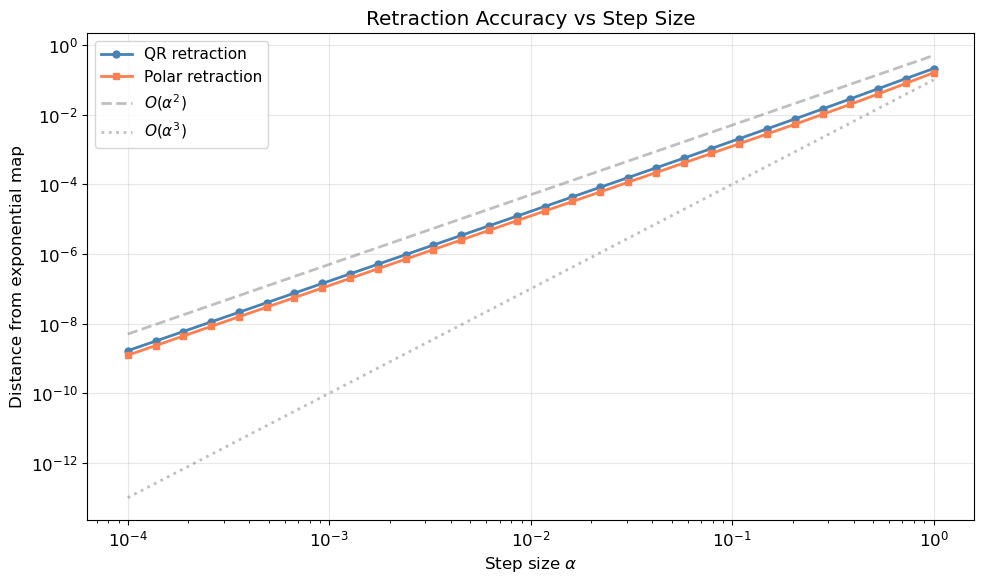

In [8]:
# =============================================================================
# Retraction Comparison: Accuracy vs Step Size
# =============================================================================

step_sizes = np.logspace(-4, 0, 30)
errors_qr = []
errors_polar = []

X_base = random_stiefel(N_DIM, P_DIM)
V_base = np.random.randn(N_DIM, P_DIM)
Z_base = stiefel_project(X_base, V_base)
Z_base = Z_base / np.linalg.norm(Z_base)  # unit tangent vector

for alpha in step_sizes:
    Z_scaled = alpha * Z_base

    # Reference: exponential map
    X_exp = stiefel_retract_exp(X_base, Z_scaled)

    # QR retraction
    X_qr = stiefel_retract_qr(X_base, Z_scaled)
    errors_qr.append(np.linalg.norm(X_qr - X_exp, 'fro'))

    # Polar retraction
    X_pol = stiefel_retract_polar(X_base, Z_scaled)
    errors_polar.append(np.linalg.norm(X_pol - X_exp, 'fro'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(step_sizes, errors_qr, 'o-', color=COLOR_PRIMARY, markersize=5, label='QR retraction')
ax.loglog(step_sizes, errors_polar, 's-', color=COLOR_SECONDARY, markersize=5, label='Polar retraction')

# Reference slopes
ax.loglog(step_sizes, 0.5 * step_sizes**2, '--', color='gray', alpha=0.5, label=r'$O(\alpha^2)$')
ax.loglog(step_sizes, 0.1 * step_sizes**3, ':', color='gray', alpha=0.5, label=r'$O(\alpha^3)$')

ax.set_xlabel('Step size $\\alpha$')
ax.set_ylabel('Distance from exponential map')
ax.set_title('Retraction Accuracy vs Step Size')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 7. Riemannian Gradient Descent

### Algorithm

The Riemannian gradient descent algorithm is the natural generalization of Euclidean gradient descent:

$$\boxed{X_{k+1} = R_{X_k}(-\alpha_k \, \text{grad} f(X_k))}$$

where:
1. $\text{grad} f(X_k) = \text{proj}_{X_k}(\nabla f(X_k))$ is the Riemannian gradient
2. $R_{X_k}$ is a retraction map
3. $\alpha_k > 0$ is the step size

**Pseudocode:**
```
Input: X_0 on M, step size alpha, tolerance eps
for k = 0, 1, 2, ...:
    1. Compute Euclidean gradient: G = nabla f(X_k)
    2. Project to tangent space: grad = proj_{X_k}(G)
    3. Check convergence: if ||grad|| < eps, stop
    4. Retract: X_{k+1} = R_{X_k}(-alpha * grad)
```

### Convergence

Under standard assumptions (Lipschitz gradient, bounded curvature), Riemannian gradient descent converges with the same rate as Euclidean gradient descent:

- **General (non-convex):** $\min_{k \le K} \|\text{grad} f(X_k)\| \le O(1/\sqrt{K})$
- **Geodesically convex:** $f(X_K) - f^* \le O(1/K)$

In [9]:
# =============================================================================
# Section 7: Riemannian Gradient Descent
# =============================================================================

def riemannian_gradient_descent(cost_fn, egrad_fn, project_fn, retract_fn,
                                X0, step_size=STEP_SIZE, max_iter=MAX_ITER,
                                grad_tol=GRAD_TOL, callback=None):
    """Riemannian gradient descent on a matrix manifold.

    Algorithm:
        X_{k+1} = retract(X_k, -alpha * proj(egrad(X_k)))

    Args:
        cost_fn: Callable, cost_fn(X) -> scalar.
        egrad_fn: Callable, egrad_fn(X) -> Euclidean gradient. Shape: same as X.
        project_fn: Callable, project_fn(X, V) -> tangent vector. Shape: same as X.
        retract_fn: Callable, retract_fn(X, Z) -> new point on manifold. Shape: same as X.
        X0: Initial point on the manifold. Shape: (n, p).
        step_size: Step size alpha. Scalar.
        max_iter: Maximum iterations. Integer.
        grad_tol: Convergence tolerance on gradient norm. Scalar.
        callback: Optional callable, callback(k, X, cost, grad_norm).

    Returns:
        X_opt: Optimized point on the manifold. Shape: (n, p).
        history: Dict with keys 'cost', 'grad_norm', 'iterates' (list of X at saved iters).
    """
    X = X0.copy()
    history = {'cost': [], 'grad_norm': [], 'iterates': [], 'orth_error': []}
    save_iters = set([0, 1, 2, 5, 10, 20, 50, 100, 200, 500])

    for k in range(max_iter):
        cost = cost_fn(X)
        egrad = egrad_fn(X)
        rgrad = project_fn(X, egrad)
        grad_norm = np.linalg.norm(rgrad, 'fro')

        # Check manifold constraint
        n, p = X.shape
        orth_err = np.max(np.abs(X.T @ X - np.eye(p)))

        history['cost'].append(cost)
        history['grad_norm'].append(grad_norm)
        history['orth_error'].append(orth_err)

        if k in save_iters:
            history['iterates'].append(X.copy())

        if callback is not None:
            callback(k, X, cost, grad_norm)

        if grad_norm < grad_tol:
            history['iterates'].append(X.copy())
            break

        # Retract
        X = retract_fn(X, -step_size * rgrad)

    return X, history

In [10]:
# =============================================================================
# Apply to Rayleigh Quotient Minimization (Eigenvalue Problem)
# =============================================================================

# Problem: minimize f(X) = -tr(X^T A X) on St(n, p)
# Solution: X* spans the top-p eigenspace of A

# Generate a symmetric PD matrix with known eigenvalues
np.random.seed(42)
eigenvalues_true = np.array([10.0, 7.0, 5.0, 2.0, 1.0])
Q_true = random_stiefel(N_DIM, N_DIM)
A_test = Q_true @ np.diag(eigenvalues_true) @ Q_true.T

# True minimum: f* = -(sum of top-p eigenvalues)
optimal_cost = -np.sum(np.sort(eigenvalues_true)[::-1][:P_DIM])
print(f"True eigenvalues: {eigenvalues_true}")
print(f"Optimal cost (sum of top-{P_DIM}): {optimal_cost:.4f}")

# Run optimization with different retractions
X0 = random_stiefel(N_DIM, P_DIM)

results = {}
for name, retract_fn in retractions.items():
    X_opt, hist = riemannian_gradient_descent(
        cost_fn=lambda X: rayleigh_quotient_cost(X, A_test),
        egrad_fn=lambda X: rayleigh_quotient_egrad(X, A_test),
        project_fn=stiefel_project,
        retract_fn=retract_fn,
        X0=X0.copy(),
        step_size=0.02,
        max_iter=MAX_ITER,
        grad_tol=GRAD_TOL,
    )
    results[name] = (X_opt, hist)
    print(f"\n{name} retraction:")
    print(f"  Final cost:     {hist['cost'][-1]:.8f} (optimal: {optimal_cost:.4f})")
    print(f"  Final grad norm: {hist['grad_norm'][-1]:.2e}")
    print(f"  Max orth error:  {max(hist['orth_error']):.2e}")
    print(f"  Iterations:      {len(hist['cost'])}")

True eigenvalues: [10.  7.  5.  2.  1.]
Optimal cost (sum of top-3): -22.0000

QR retraction:
  Final cost:     -22.00000000 (optimal: -22.0000)
  Final grad norm: 9.63e-09
  Max orth error:  1.11e-15
  Iterations:      158

Polar retraction:
  Final cost:     -22.00000000 (optimal: -22.0000)
  Final grad norm: 9.63e-09
  Max orth error:  1.78e-15
  Iterations:      158

Exp retraction:
  Final cost:     -22.00000000 (optimal: -22.0000)
  Final grad norm: 9.61e-09
  Max orth error:  6.66e-16
  Iterations:      158


In [11]:
# ---- Verification: Iterates stay on manifold ----
print("Manifold constraint verification (all iterates X^T X = I):")
for name, (X_opt, hist) in results.items():
    max_orth = max(hist['orth_error'])
    status = "PASS" if max_orth < 1e-10 else "FAIL"
    print(f"  {name:6s}: max |X^T X - I| over all iterates = {max_orth:.2e} [{status}]")

Manifold constraint verification (all iterates X^T X = I):
  QR    : max |X^T X - I| over all iterates = 1.11e-15 [PASS]
  Polar : max |X^T X - I| over all iterates = 1.78e-15 [PASS]
  Exp   : max |X^T X - I| over all iterates = 6.66e-16 [PASS]


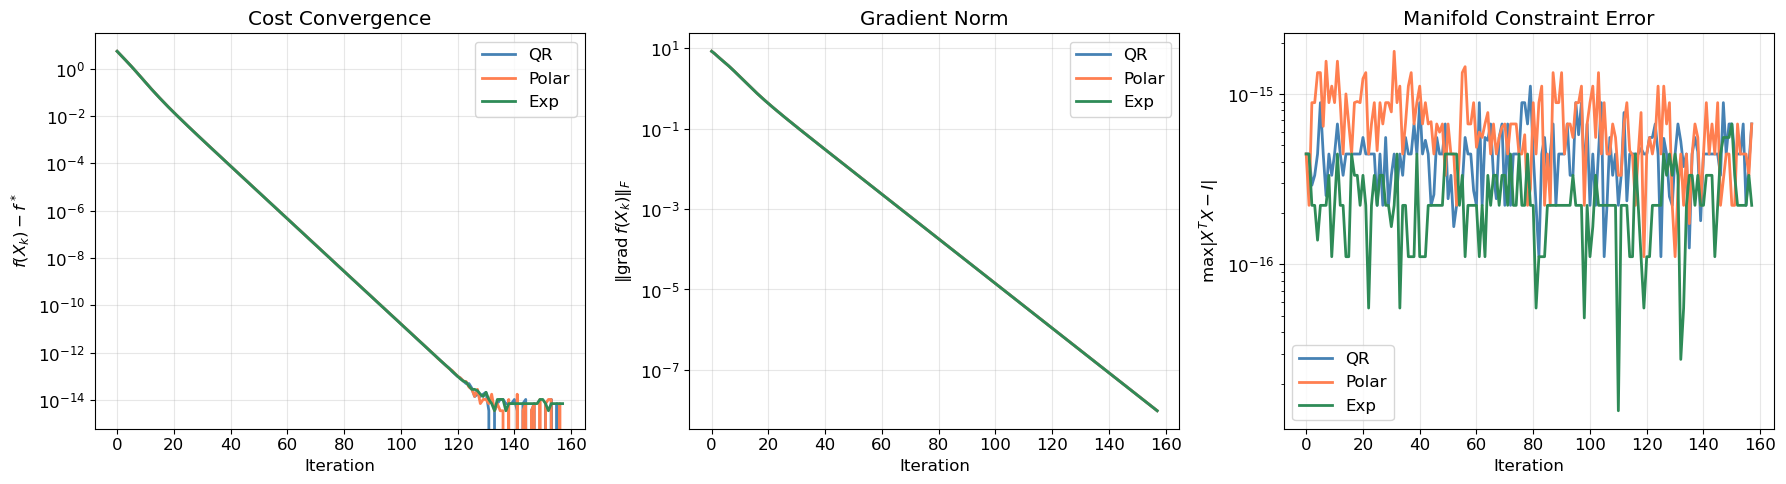

In [12]:
# ---- 3-Panel Figure: Convergence Comparison ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ret_colors = {'QR': COLOR_PRIMARY, 'Polar': COLOR_SECONDARY, 'Exp': COLOR_TERTIARY}

# Panel 1: Cost convergence
ax = axes[0]
for name, (_, hist) in results.items():
    ax.semilogy(np.array(hist['cost']) - optimal_cost, color=ret_colors[name],
                linewidth=2, label=name)
ax.set_xlabel('Iteration')
ax.set_ylabel('$f(X_k) - f^*$')
ax.set_title('Cost Convergence')
ax.legend()

# Panel 2: Gradient norm
ax = axes[1]
for name, (_, hist) in results.items():
    ax.semilogy(hist['grad_norm'], color=ret_colors[name], linewidth=2, label=name)
ax.set_xlabel('Iteration')
ax.set_ylabel('$\\|\\mathrm{grad}\\, f(X_k)\\|_F$')
ax.set_title('Gradient Norm')
ax.legend()

# Panel 3: Manifold constraint error
ax = axes[2]
for name, (_, hist) in results.items():
    ax.semilogy(hist['orth_error'], color=ret_colors[name], linewidth=2, label=name)
ax.set_xlabel('Iteration')
ax.set_ylabel('$\\max |X^T X - I|$')
ax.set_title('Manifold Constraint Error')
ax.legend()

plt.tight_layout()
plt.show()

---
## 8. Application: Rotation Averaging on SO(3)

### Problem Statement

Given $N$ noisy rotation measurements $\{R_i\}_{i=1}^N$ in $SO(3)$, find the **Karcher (Frechet) mean**:

$$\bar{R} = \arg\min_{R \in SO(3)} \sum_{i=1}^N d^2(R, R_i)$$

where $d(R, R_i) = \|\log(R^T R_i)\|_F / \sqrt{2}$ is the geodesic distance on $SO(3)$.

### Connection to Lie Groups

$SO(3)$ is a Lie group with Lie algebra $\mathfrak{so}(3)$ (the space of $3 \times 3$ skew-symmetric matrices). The key operations are:

- **Exponential map:** $\exp : \mathfrak{so}(3) \to SO(3)$ maps a skew-symmetric matrix to a rotation (Rodrigues' formula)
- **Logarithmic map:** $\log : SO(3) \to \mathfrak{so}(3)$ extracts the rotation axis and angle

### Algorithm: Riemannian Gradient Descent on SO(3)

The Riemannian gradient of $f(R) = \sum_i \|\log(R^T R_i)\|_F^2 / 2$ at $R$ is:

$$\text{grad} f(R) = -R \sum_{i=1}^N \log(R^T R_i)$$

The retraction is the exponential map:

$$R_{k+1} = R_k \, \exp\!\left(\alpha \sum_{i=1}^N \log(R_k^T R_i)\right)$$

In [13]:
# =============================================================================
# Section 8: Rotation Averaging on SO(3)
# =============================================================================

def skew_symmetric(v):
    """Create a 3x3 skew-symmetric matrix from a 3-vector.

    [v]_x such that [v]_x @ w = v x w (cross product).

    Args:
        v: 3-vector. Shape: (3,).

    Returns:
        Skew-symmetric matrix. Shape: (3, 3).
    """
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])


def so3_exp(Omega):
    """Exponential map from so(3) to SO(3) via Rodrigues' formula.

    exp(Omega) = I + sin(theta)/theta * Omega + (1-cos(theta))/theta^2 * Omega^2

    Args:
        Omega: Skew-symmetric matrix. Shape: (3, 3).

    Returns:
        Rotation matrix. Shape: (3, 3).
    """
    # Extract angle
    theta = np.sqrt(0.5 * np.trace(Omega.T @ Omega))
    if theta < 1e-12:
        return np.eye(3) + Omega
    return (np.eye(3)
            + np.sin(theta) / theta * Omega
            + (1 - np.cos(theta)) / theta**2 * (Omega @ Omega))


def so3_log(R):
    """Logarithmic map from SO(3) to so(3).

    Returns the skew-symmetric matrix Omega such that exp(Omega) = R.

    Args:
        R: Rotation matrix. Shape: (3, 3).

    Returns:
        Skew-symmetric matrix. Shape: (3, 3).
    """
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    if theta < 1e-12:
        return np.zeros((3, 3))

    if abs(theta - np.pi) < 1e-6:
        # Near pi: use eigendecomposition
        eigvals, eigvecs = np.linalg.eigh(R)
        # The eigenvector with eigenvalue +1 is the rotation axis
        idx = np.argmin(np.abs(eigvals - 1.0))
        axis = eigvecs[:, idx]
        return theta * skew_symmetric(axis)

    return theta / (2 * np.sin(theta)) * (R - R.T)


def random_rotation():
    """Generate a uniformly random rotation matrix in SO(3).

    Uses QR decomposition of a random Gaussian matrix.

    Returns:
        Random rotation matrix. Shape: (3, 3).
    """
    A = np.random.randn(3, 3)
    Q, R = np.linalg.qr(A)
    # Ensure det(Q) = +1
    Q = Q @ np.diag(np.sign(np.diag(R)))
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q


def noisy_rotation(R_true, noise_level):
    """Generate a noisy rotation by perturbing R_true.

    R_noisy = R_true @ exp(noise_level * Omega_random).

    Args:
        R_true: True rotation matrix. Shape: (3, 3).
        noise_level: Standard deviation of perturbation. Scalar.

    Returns:
        Noisy rotation matrix. Shape: (3, 3).
    """
    v = noise_level * np.random.randn(3)
    Omega = skew_symmetric(v)
    return R_true @ so3_exp(Omega)

In [14]:
def rotation_average_so3(rotations, step_size=0.5, max_iter=200, tol=1e-10):
    """Compute the Karcher/Frechet mean of rotations on SO(3).

    Uses Riemannian gradient descent with the exponential map.
    f(R) = sum_i ||log(R^T R_i)||_F^2 / 2
    grad f(R) = -R * sum_i log(R^T R_i)
    Update: R <- R exp(alpha * sum_i log(R^T R_i))

    Args:
        rotations: List of rotation matrices. Each shape: (3, 3).
        step_size: Step size for gradient descent. Scalar.
        max_iter: Maximum iterations. Integer.
        tol: Convergence tolerance on gradient norm. Scalar.

    Returns:
        R_mean: Frechet mean rotation. Shape: (3, 3).
        history: Dict with keys 'cost', 'grad_norm', 'so3_error'.
    """
    N = len(rotations)
    R = rotations[0].copy()  # initialize with first rotation

    history = {'cost': [], 'grad_norm': [], 'so3_error': []}

    for k in range(max_iter):
        # Compute sum of log maps
        log_sum = np.zeros((3, 3))
        cost = 0.0
        for Ri in rotations:
            log_RtRi = so3_log(R.T @ Ri)
            log_sum += log_RtRi
            cost += 0.5 * np.trace(log_RtRi.T @ log_RtRi)

        # Riemannian gradient in the Lie algebra: -sum_i log(R^T R_i)
        # (negative because we minimize)
        delta = log_sum / N  # average log map
        grad_norm = np.linalg.norm(delta, 'fro')

        # Check SO(3) membership
        so3_err = np.max(np.abs(R.T @ R - np.eye(3)))

        history['cost'].append(cost / N)
        history['grad_norm'].append(grad_norm)
        history['so3_error'].append(so3_err)

        if grad_norm < tol:
            break

        # Update: R <- R * exp(step_size * delta)
        R = R @ so3_exp(step_size * delta)

    return R, history


# Verify exp and log are inverses
R_verify = random_rotation()
Omega_verify = so3_log(R_verify)
R_reconstructed = so3_exp(Omega_verify)
exp_log_err = np.max(np.abs(R_verify - R_reconstructed))
status_el = "PASS" if exp_log_err < 1e-10 else "FAIL"
print(f"SO(3) exp-log round-trip: max error = {exp_log_err:.2e} [{status_el}]")

# Verify log-exp
v_test = np.array([0.3, -0.5, 0.7])
Omega_test2 = skew_symmetric(v_test)
R_from_exp = so3_exp(Omega_test2)
Omega_recovered = so3_log(R_from_exp)
log_exp_err = np.max(np.abs(Omega_test2 - Omega_recovered))
status_le = "PASS" if log_exp_err < 1e-10 else "FAIL"
print(f"SO(3) log-exp round-trip: max error = {log_exp_err:.2e} [{status_le}]")

SO(3) exp-log round-trip: max error = 1.33e-15 [PASS]
SO(3) log-exp round-trip: max error = 1.11e-16 [PASS]


In [15]:
# =============================================================================
# Run Rotation Averaging
# =============================================================================

np.random.seed(42)

# Generate ground truth rotation
R_true = random_rotation()
print(f"True rotation (det = {np.linalg.det(R_true):.6f}):")
print(R_true.round(4))

# Generate noisy measurements
rotations_noisy = [noisy_rotation(R_true, NOISE_LEVEL) for _ in range(N_ROTATIONS)]

# Compute Frechet mean
R_mean, rot_hist = rotation_average_so3(rotations_noisy, step_size=0.5, max_iter=200)

# Error metrics
geodesic_error = np.linalg.norm(so3_log(R_true.T @ R_mean), 'fro') / np.sqrt(2)
frobenius_error = np.linalg.norm(R_true - R_mean, 'fro')

print(f"\nFrechet mean (det = {np.linalg.det(R_mean):.6f}):")
print(R_mean.round(4))
print(f"\nGeodesic distance to true: {geodesic_error:.6f} rad")
print(f"Frobenius distance to true: {frobenius_error:.6f}")
print(f"Converged in {len(rot_hist['cost'])} iterations")

status_conv = "PASS" if geodesic_error < 0.1 else "FAIL"
print(f"\nRotation average converges to true mean: geodesic error = {geodesic_error:.2e} [{status_conv}]")

True rotation (det = 1.000000):
[[ 0.2208 -0.2931  0.9302]
 [ 0.6771 -0.6405 -0.3625]
 [ 0.702   0.7099  0.057 ]]

Frechet mean (det = 1.000000):
[[ 0.2463 -0.3075  0.9191]
 [ 0.6833 -0.6175 -0.3897]
 [ 0.6874  0.724   0.058 ]]

Geodesic distance to true: 0.036799 rad
Frobenius distance to true: 0.052039
Converged in 32 iterations

Rotation average converges to true mean: geodesic error = 3.68e-02 [PASS]


---
## 9. Visualizations

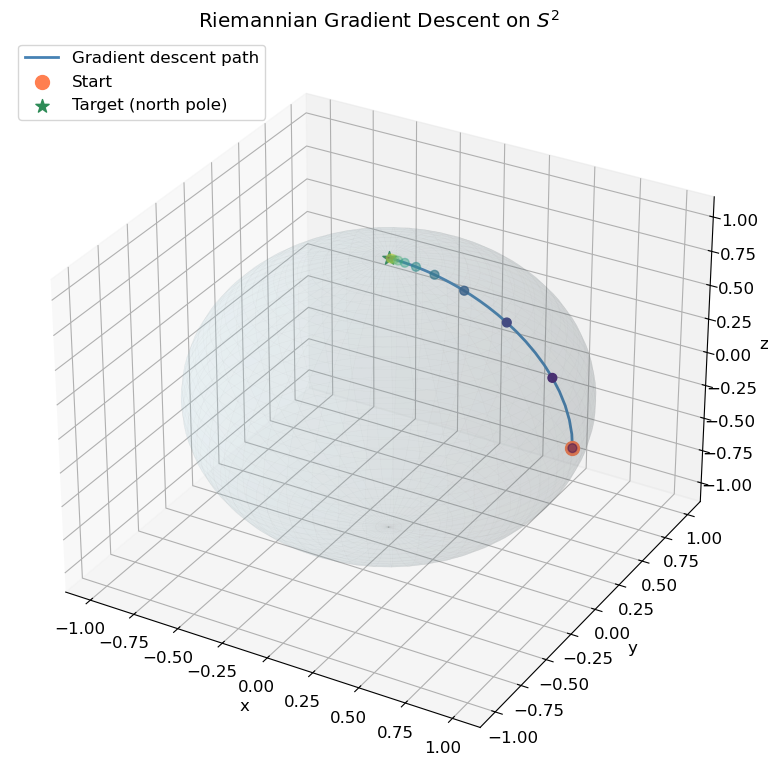

In [16]:
# =============================================================================
# Visualization 1: Gradient Descent on S^2
# =============================================================================

def sphere_cost(x, a):
    """Cost function on S^2: f(x) = -a^T x (find point closest to a).

    Args:
        x: Point on S^2. Shape: (3,).
        a: Target direction. Shape: (3,).

    Returns:
        Cost value. Scalar.
    """
    return -np.dot(a, x)


def sphere_egrad(x, a):
    """Euclidean gradient of f(x) = -a^T x.

    Args:
        x: Point on S^2. Shape: (3,).
        a: Target direction. Shape: (3,).

    Returns:
        Euclidean gradient. Shape: (3,).
    """
    return -a


# Target direction (normalized)
a_target = np.array([0.0, 0.0, 1.0])

# Starting point on S^2
x0_sphere = np.array([1.0, 0.0, 0.0])

# Run gradient descent on the sphere
trajectory_sphere = [x0_sphere.copy()]
x_current = x0_sphere.copy()

for k in range(50):
    eg = sphere_egrad(x_current, a_target)
    rg = sphere_tangent_project(x_current, eg)

    # Retract: normalize (exponential map on sphere = geodesic)
    x_next = x_current - 0.1 * rg
    x_next = x_next / np.linalg.norm(x_next)
    trajectory_sphere.append(x_next.copy())
    x_current = x_next

trajectory_sphere = np.array(trajectory_sphere)

# Plot 3D trajectory on sphere
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Sphere wireframe
u = np.linspace(0, 2 * np.pi, N_SPHERE_POINTS)
v = np.linspace(0, np.pi, N_SPHERE_POINTS)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xs, ys, zs, alpha=0.1, color='lightblue')
ax.plot_wireframe(xs, ys, zs, alpha=0.05, color='gray', linewidth=0.3)

# Trajectory
colors_traj = plt.cm.viridis(np.linspace(0, 1, len(trajectory_sphere)))
ax.plot(trajectory_sphere[:, 0], trajectory_sphere[:, 1], trajectory_sphere[:, 2],
        '-', color=COLOR_PRIMARY, linewidth=2, label='Gradient descent path')
ax.scatter(trajectory_sphere[::5, 0], trajectory_sphere[::5, 1], trajectory_sphere[::5, 2],
           c=range(0, len(trajectory_sphere), 5), cmap='viridis', s=40, zorder=5)

# Start and end points
ax.scatter(*x0_sphere, color=COLOR_SECONDARY, s=100, zorder=10, label='Start')
ax.scatter(*a_target, color=COLOR_TERTIARY, s=100, marker='*', zorder=10, label='Target (north pole)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Riemannian Gradient Descent on $S^2$')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

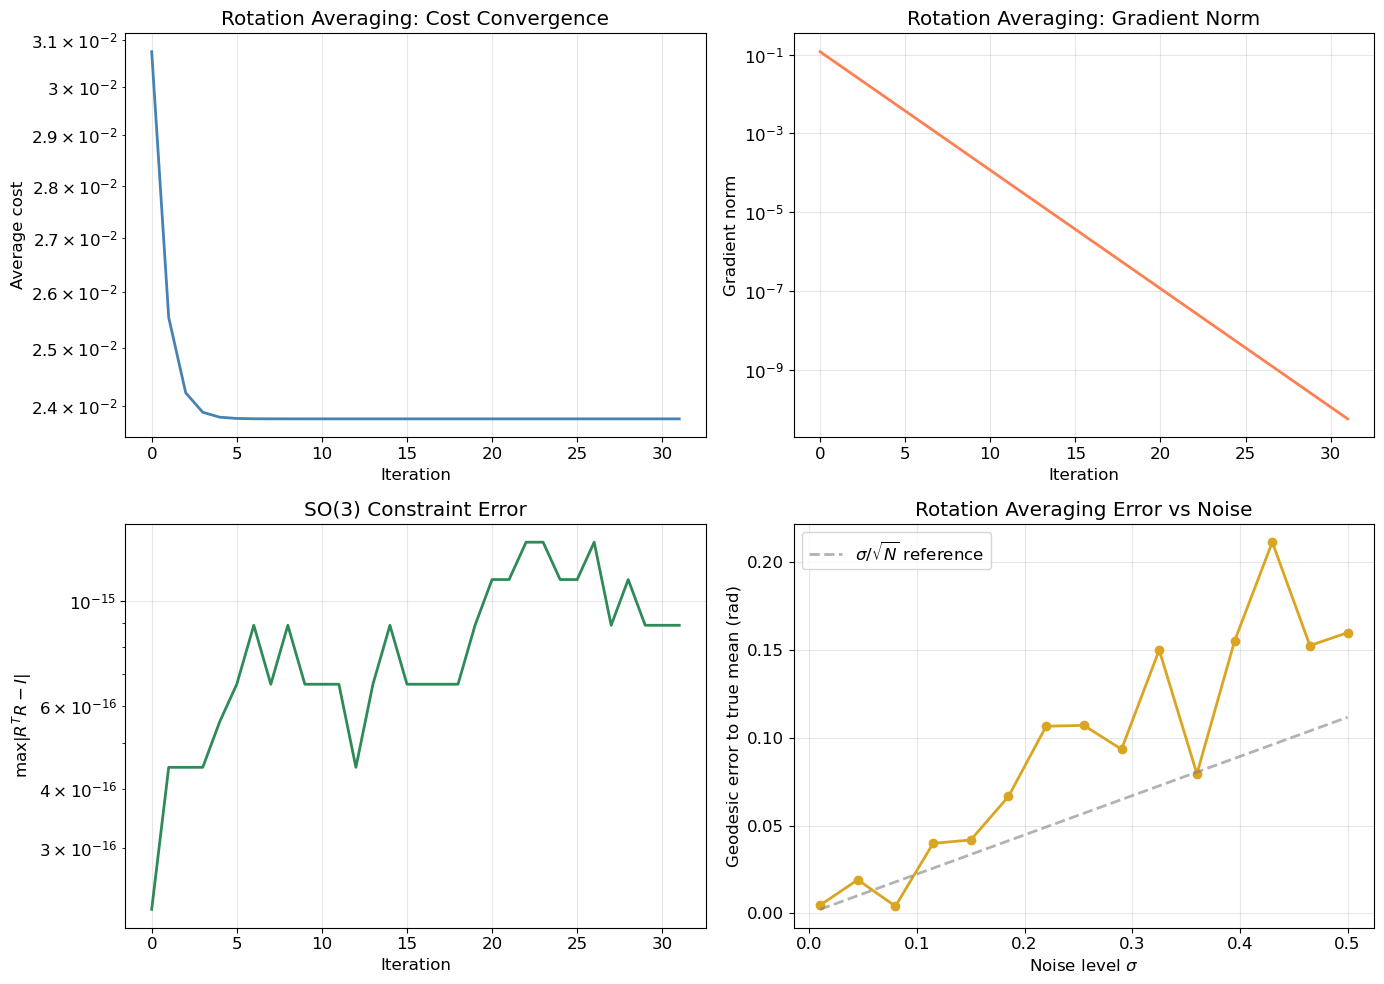

In [17]:
# =============================================================================
# Visualization 2: Rotation Averaging Results (4-panel)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Cost convergence
ax = axes[0, 0]
ax.semilogy(rot_hist['cost'], color=COLOR_PRIMARY, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Average cost')
ax.set_title('Rotation Averaging: Cost Convergence')

# Panel 2: Gradient norm
ax = axes[0, 1]
ax.semilogy(rot_hist['grad_norm'], color=COLOR_SECONDARY, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Gradient norm')
ax.set_title('Rotation Averaging: Gradient Norm')

# Panel 3: SO(3) constraint error
ax = axes[1, 0]
ax.semilogy(rot_hist['so3_error'], color=COLOR_TERTIARY, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('$\\max |R^T R - I|$')
ax.set_title('SO(3) Constraint Error')

# Panel 4: Error vs noise level
ax = axes[1, 1]
noise_levels = np.linspace(0.01, 0.5, 15)
geodesic_errors = []

np.random.seed(123)
R_true_sweep = random_rotation()

for nl in noise_levels:
    rots = [noisy_rotation(R_true_sweep, nl) for _ in range(N_ROTATIONS)]
    R_avg, _ = rotation_average_so3(rots, step_size=0.5, max_iter=200)
    err = np.linalg.norm(so3_log(R_true_sweep.T @ R_avg), 'fro') / np.sqrt(2)
    geodesic_errors.append(err)

ax.plot(noise_levels, geodesic_errors, 'o-', color=COLOR_ACCENT, linewidth=2, markersize=6)
# Reference line: error proportional to noise / sqrt(N)
ax.plot(noise_levels, noise_levels / np.sqrt(N_ROTATIONS), '--', color='gray',
        alpha=0.6, label=r'$\sigma / \sqrt{N}$ reference')
ax.set_xlabel('Noise level $\\sigma$')
ax.set_ylabel('Geodesic error to true mean (rad)')
ax.set_title('Rotation Averaging Error vs Noise')
ax.legend()

plt.tight_layout()
plt.show()

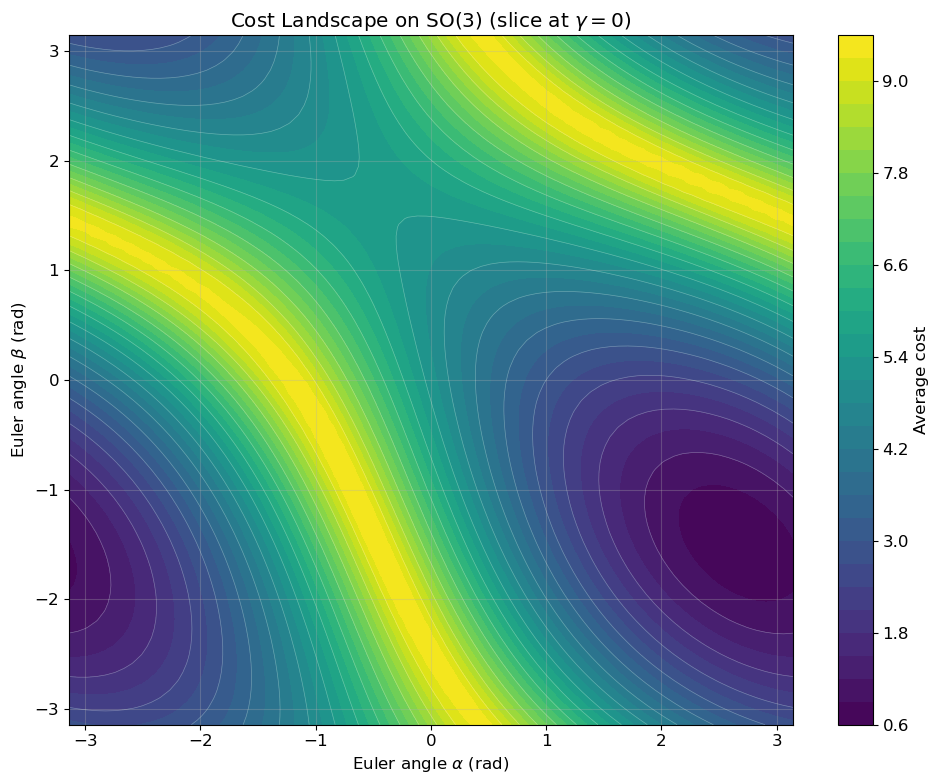

In [18]:
# =============================================================================
# Visualization 3: Cost Landscape on SO(3) via Euler Angles
# =============================================================================

def euler_to_rotation(alpha, beta, gamma):
    """Convert ZYZ Euler angles to rotation matrix.

    R = Rz(alpha) @ Ry(beta) @ Rz(gamma).

    Args:
        alpha: First rotation angle (rad). Scalar.
        beta: Second rotation angle (rad). Scalar.
        gamma: Third rotation angle (rad). Scalar.

    Returns:
        Rotation matrix. Shape: (3, 3).
    """
    ca, sa = np.cos(alpha), np.sin(alpha)
    cb, sb = np.cos(beta), np.sin(beta)
    cg, sg = np.cos(gamma), np.sin(gamma)

    Rz1 = np.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])
    Ry = np.array([[cb, 0, sb], [0, 1, 0], [-sb, 0, cb]])
    Rz2 = np.array([[cg, -sg, 0], [sg, cg, 0], [0, 0, 1]])

    return Rz1 @ Ry @ Rz2


# Evaluate cost on a 2D slice of SO(3)
n_grid = 80
alpha_range = np.linspace(-np.pi, np.pi, n_grid)
beta_range = np.linspace(-np.pi, np.pi, n_grid)
cost_landscape = np.zeros((n_grid, n_grid))

for i, a in enumerate(alpha_range):
    for j, b in enumerate(beta_range):
        R_eval = euler_to_rotation(a, b, 0)
        total_cost = 0.0
        for Ri in rotations_noisy:
            log_val = so3_log(R_eval.T @ Ri)
            total_cost += 0.5 * np.trace(log_val.T @ log_val)
        cost_landscape[j, i] = total_cost / N_ROTATIONS

fig, ax = plt.subplots(figsize=(10, 8))
cf = ax.contourf(alpha_range, beta_range, cost_landscape, levels=30, cmap='viridis')
ax.contour(alpha_range, beta_range, cost_landscape, levels=15, colors='white', linewidths=0.5, alpha=0.3)
plt.colorbar(cf, ax=ax, label='Average cost')

ax.set_xlabel(r'Euler angle $\alpha$ (rad)')
ax.set_ylabel(r'Euler angle $\beta$ (rad)')
ax.set_title(r'Cost Landscape on SO(3) (slice at $\gamma = 0$)')

plt.tight_layout()
plt.show()

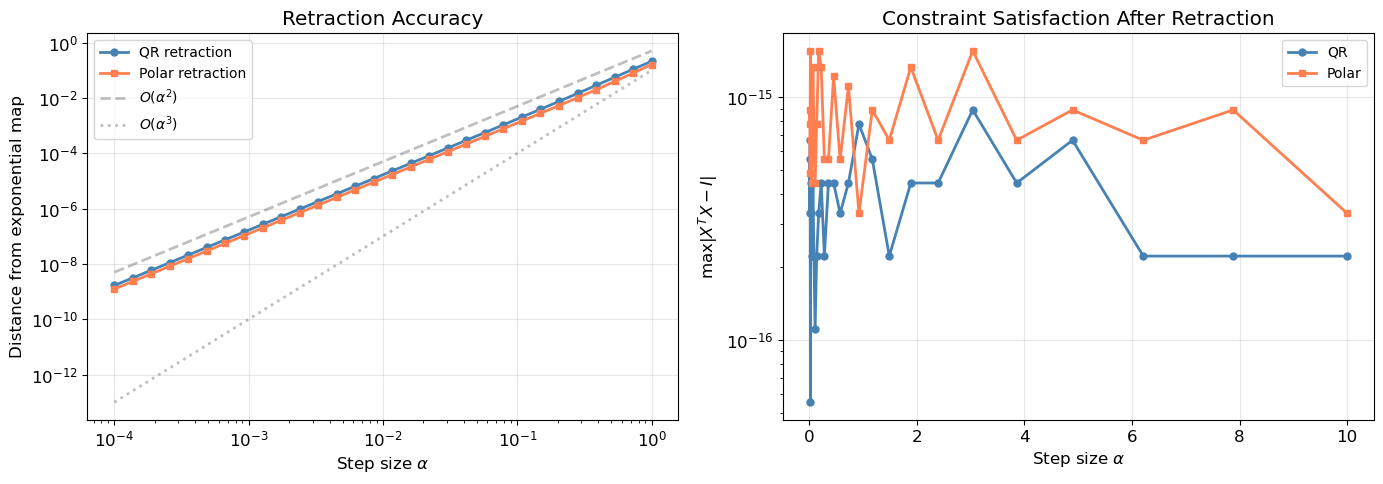

In [19]:
# =============================================================================
# Visualization 4: Retraction Comparison (accuracy vs step size, revisited)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distance from exponential map
ax = axes[0]
ax.loglog(step_sizes, errors_qr, 'o-', color=COLOR_PRIMARY, markersize=5, label='QR retraction')
ax.loglog(step_sizes, errors_polar, 's-', color=COLOR_SECONDARY, markersize=5, label='Polar retraction')
ax.loglog(step_sizes, 0.5 * step_sizes**2, '--', color='gray', alpha=0.5, label=r'$O(\alpha^2)$')
ax.loglog(step_sizes, 0.1 * step_sizes**3, ':', color='gray', alpha=0.5, label=r'$O(\alpha^3)$')
ax.set_xlabel('Step size $\\alpha$')
ax.set_ylabel('Distance from exponential map')
ax.set_title('Retraction Accuracy')
ax.legend(fontsize=10)

# Right: Manifold constraint violation after retraction
ax = axes[1]
orth_errs_qr = []
orth_errs_polar = []
large_steps = np.logspace(-2, 1, 30)

X_base2 = random_stiefel(N_DIM, P_DIM)
V_base2 = np.random.randn(N_DIM, P_DIM)
Z_base2 = stiefel_project(X_base2, V_base2)
Z_base2 = Z_base2 / np.linalg.norm(Z_base2)

for alpha in large_steps:
    Z_s = alpha * Z_base2

    X_qr2 = stiefel_retract_qr(X_base2, Z_s)
    orth_errs_qr.append(np.max(np.abs(X_qr2.T @ X_qr2 - np.eye(P_DIM))))

    X_pol2 = stiefel_retract_polar(X_base2, Z_s)
    orth_errs_polar.append(np.max(np.abs(X_pol2.T @ X_pol2 - np.eye(P_DIM))))

ax.semilogy(large_steps, orth_errs_qr, 'o-', color=COLOR_PRIMARY, markersize=5, label='QR')
ax.semilogy(large_steps, orth_errs_polar, 's-', color=COLOR_SECONDARY, markersize=5, label='Polar')
ax.set_xlabel('Step size $\\alpha$')
ax.set_ylabel('$\\max |X^T X - I|$')
ax.set_title('Constraint Satisfaction After Retraction')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 10. Extensions

This notebook has covered the foundations of optimization on matrix manifolds. Several important extensions are actively used in research and applications:

### Riemannian Conjugate Gradient

Just as conjugate gradient (CG) accelerates gradient descent in Euclidean space, **Riemannian CG** accelerates convergence on manifolds. The key challenge is that tangent vectors at different points live in different vector spaces, so we need **vector transport** to move the previous search direction to the current tangent space:

$$\eta_{k+1} = -\text{grad} f(X_{k+1}) + \beta_k \, \mathcal{T}_{X_k \to X_{k+1}}(\eta_k)$$

where $\mathcal{T}$ is a vector transport operator and $\beta_k$ is chosen by a Riemannian analogue of Fletcher-Reeves, Polak-Ribiere, or Hestenes-Stiefel formulas.

### Riemannian Trust-Region Methods

Trust-region methods on manifolds (RTR) achieve **superlinear convergence** by solving a quadratic subproblem on the tangent space at each step:

$$\min_{\eta \in T_X \mathcal{M}, \|\eta\| \le \Delta} \; \langle \text{grad} f, \eta \rangle + \frac{1}{2} \langle \text{Hess} f[\eta], \eta \rangle$$

The Riemannian Hessian requires the **Levi-Civita connection**, which encodes how tangent spaces twist along the manifold. These methods are implemented in the Manopt library.

### Low-Rank Matrix Optimization

The set of $m \times n$ matrices of fixed rank $r$ forms a smooth manifold of dimension $r(m + n - r)$. Optimization on this manifold is fundamental to:

- **Matrix completion** (Netflix problem): recover a low-rank matrix from partial observations
- **Robust PCA**: decompose a matrix into low-rank + sparse components
- **Tensor decomposition**: factor high-dimensional data arrays

The tangent space at a rank-$r$ matrix $X = U \Sigma V^T$ has a convenient parametrization in terms of the factors $U, \Sigma, V$.

### Key Takeaways

1. **Matrix constraints define manifolds** -- orthogonality, fixed rank, positive definiteness all have manifold structure
2. **The Riemannian gradient** is just the projected Euclidean gradient -- simple to implement
3. **Retractions** map tangent vectors back to the manifold -- QR is cheap, polar is more accurate
4. **Manifold optimization respects constraints exactly** -- no penalty tuning, no constraint violation
5. **SO(3) averaging** via the Karcher mean is a canonical application connecting manifold optimization to robotics, computer vision, and Lie group theory

### Further Reading

- Absil, Mahony & Sepulchre, *Optimization Algorithms on Matrix Manifolds*, Princeton, 2008.
- Boumal, *An Introduction to Optimization on Smooth Manifolds*, Cambridge, 2023.
- Manopt toolbox: [manopt.org](https://www.manopt.org) (MATLAB) and [pymanopt.org](https://www.pymanopt.org) (Python)
- Boumal et al., *Manopt, a Matlab Toolbox for Optimization on Manifolds*, JMLR, 2014.